In [1]:
import sys

sys.path.append('/scratch2/mrenaudin/colorlessgreenRNNs')


In [2]:
import torch
from src.language_models.dictionary_corpus import Dictionary
from src.language_models.model import CBR_RNN
from evaluation_notebooks.utils import NounPPDataset
from torch.utils.data import DataLoader
from collections import defaultdict
from wm_tests.utils import CBR_RNN_attn_tracking, WMTestDataset, collate_fn, eval, plot_attention
import numpy as np
import pandas as pd

/home/mrenaudin/.conda/envs/leaps3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cpu')

In [39]:
model = CBR_RNN_attn_tracking(50001, 128, 128, 1, 0, device)
check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/cbr_1h_128_gumbel_softmax/epoch_40.pt', map_location = 'cpu')
model.load_state_dict(check['model_state_dict'])

<All keys matched successfully>

In [13]:
sentence_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce3_repeat.txt'
marker_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce3_repeat_markers.txt'
data_path = "/scratch2/mrenaudin/colorlessgreenRNNs/english_data"
dictionary = Dictionary(data_path)
wm_dataset = WMTestDataset(sentence_path, marker_path, dictionary)

In [44]:

test_dataloader = DataLoader(wm_dataset, batch_size=1, collate_fn=collate_fn)

In [18]:
for i in test_dataloader:
    print(i)
    break

{'sentence': [['Before', 'the', 'meeting', ',', 'Mary', 'wrote', 'down', 'the', 'following', 'list', 'of', 'words', ':', 'window', ',', 'door', ',', 'roof', '.', 'After', 'the', 'meeting', ',', 'she', 'took', 'a', 'break', 'and', 'had', 'a', 'cup', 'of', 'coffee', '.', 'When', 'she', 'got', 'back', ',', 'she', 'read', 'the', 'list', 'again', ':', 'window', ',', 'door', ',', 'roof', '.'], ['Before', 'the', 'meeting', ',', 'Mary', 'wrote', 'down', 'the', 'following', 'list', 'of', 'words', ':', 'hall', ',', 'window', ',', 'door', '.', 'After', 'the', 'meeting', ',', 'she', 'took', 'a', 'break', 'and', 'had', 'a', 'cup', 'of', 'coffee', '.', 'When', 'she', 'got', 'back', ',', 'she', 'read', 'the', 'list', 'again', ':', 'hall', ',', 'window', ',', 'door', '.'], ['Before', 'the', 'meeting', ',', 'Mary', 'wrote', 'down', 'the', 'following', 'list', 'of', 'words', ':', 'hearth', ',', 'hall', ',', 'window', '.', 'After', 'the', 'meeting', ',', 'she', 'took', 'a', 'break', 'and', 'had', 'a', 'c

In [19]:
surprisal, attention, encoded_sentence = eval(model, test_dataloader, nheads=1, temperature=1, gs=False)

In [20]:
attention[40].shape

torch.Size([230, 1, 1, 41])

# How many tokens attended for different gumbel softmax temperature ? 

In [42]:
gs = [1, 0.75, 0.5, 0.25, 0.1, 0.075, 0.05, 0.025, 0.01]
results=[]
for t in gs : 
    surprisal, attention, encoded_sentence = eval(model, test_dataloader, nheads=1, temperature=t, gs=True)
    attn = attention[-1].squeeze()

    len_sentence = attn.shape[1]
    
    max_diff = []
    sharpness = []
    #argmax_diff=[]
    for j in range(attn.shape[0]):
        differences = []
        for i in range(1, len_sentence):
            differences.append(attn[j, i-1] - attn[j,i])

        max_diff_p = np.max(differences)
        max_diff.append(max_diff_p)
        #argmax_diff_p = np.argmax(differences)
        #argmax_diff.append(argmax_diff_p)
        vec = attn[j].detach().cpu().numpy()  # 1D attention vector, shape (seq_len,)
        max_val = np.max(vec)
        min_val = np.min(vec)
        closer_to_max = np.sum(np.abs(vec - max_val) < np.abs(vec - min_val))
        sharpness.append(closer_to_max)  
        
    results.append({
        "gs": t,
        "mean_max_diff": np.median(max_diff),
        "mean_sharpness": np.mean(sharpness)
    })
df = pd.DataFrame(results)

In [43]:
df

,gs,mean_max_diff,mean_sharpness
0,1.000,0.006162,16.813043
1,0.750,0.008194,16.000000
2,0.500,0.013024,14.195652
3,0.250,0.032812,10.160870
4,0.100,0.114735,4.908696
5,0.075,0.226112,2.478261
6,0.050,0.250561,2.213043
7,0.025,0.572023,1.152174
8,0.010,0.999660,1.043478


# Plot attention

In [45]:
model = CBR_RNN_attn_tracking(50001, 128, 128, 1, 0, device)
# check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/cbr_1h_128_gumbel_softmax/epoch_40.pt', map_location = 'cpu')
# model.load_state_dict(check['model_state_dict'])

In [46]:
surprisal, attention, encoded_sentence = eval(model, test_dataloader, nheads=1, temperature=0.1, gs=True)

In [47]:
attention[15]

tensor([[[[2.8632e-04, 7.0915e-04, 7.6756e-07, 1.6977e-03, 4.6731e-05,
           8.0618e-07, 9.2102e-07, 1.6931e-03, 1.2423e-04, 9.6150e-05,
           9.9325e-01, 3.0181e-04, 1.6758e-03, 8.4206e-05, 8.4161e-07,
           2.9283e-05]]]])

In [48]:
att_matrix = torch.zeros((len(attention), len(attention)))  # 50 x 50

for t in range(len(attention)):
    att_t = attention[t].squeeze()  # shape: (t+1,)
    att_matrix[t, :t+1] = att_t


In [49]:
encoded_sentence = encoded_sentence.squeeze(0)
sentence = [
    dictionary.idx2word[int(word)] if int(word) < len(dictionary.idx2word) else "<unk>"
    for word in encoded_sentence
]


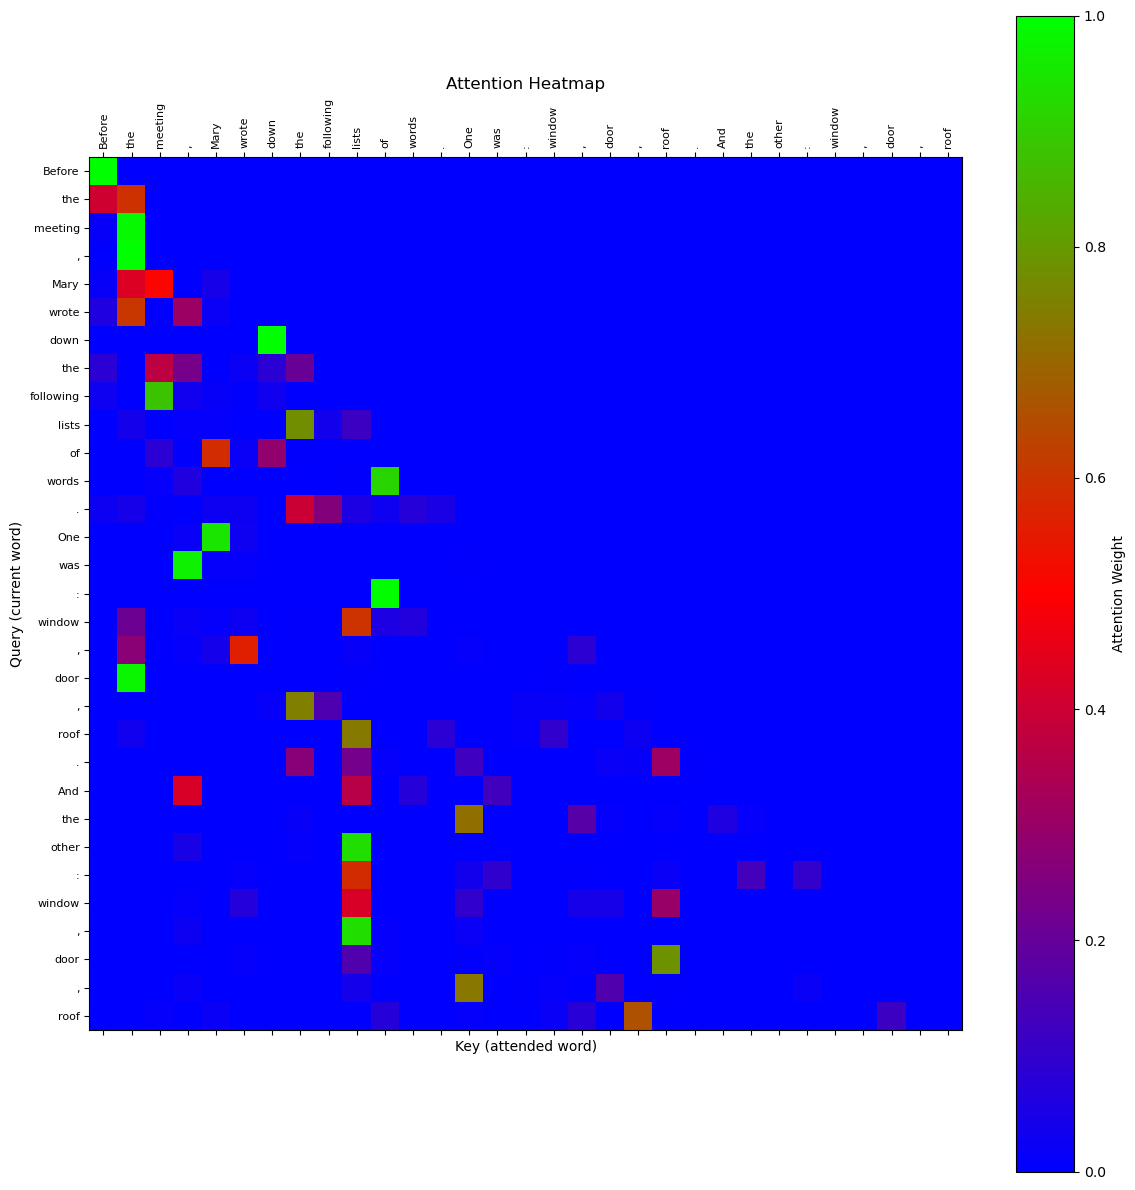

In [50]:
plot_attention(att_matrix, sentence)

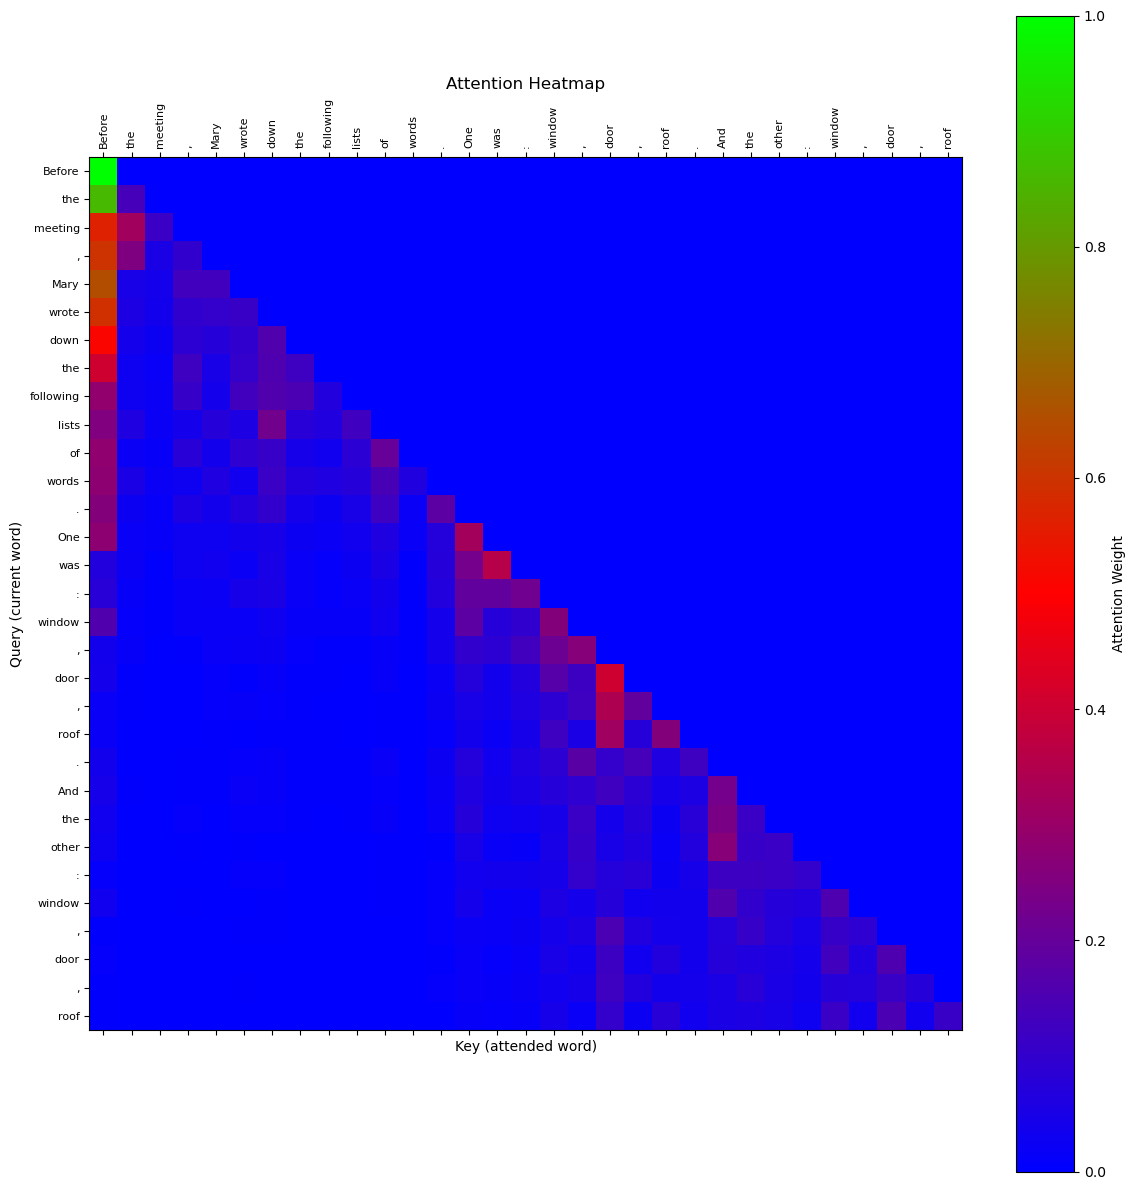

In [38]:
plot_attention(att_matrix, sentence)